# MVP: Detecção de Eventos Indesejáveis em Poços de Petróleo Offshore com o 3W Dataset (Petrobras)

Este notebook documenta o desenvolvimento de um produto mínimo viável (MVP) de Machine Learning voltado à classificação binária de eventos indesejáveis em poços de petróleo offshore, a partir de dados reais de sensoriamento. A solução foi concebida para execução integral no Google Colab, dispensando upload manual, autenticação ou chaves de acesso, e empregando exclusivamente dados de domínio público.

O trabalho está estruturado no formato de relatório técnico executável: cada etapa de processamento é implementada em código e imediatamente sucedida por uma célula textual que apresenta as observações pertinentes e justifica as decisões metodológicas adotadas, de modo a preservar a coerência e a rastreabilidade da análise do início ao fim.


## 1. Apresentação do problema

Em poços de petróleo offshore, um conjunto de sensores monitora continuamente variáveis como pressão, temperatura, vazão e o estado de válvulas. A ocorrência de eventos indesejáveis (tais como o fechamento espúrio de válvula, a formação de hidrato ou a golfada severa) está associada a perdas de produção, riscos operacionais e implicações de segurança. A detecção precoce desses eventos a partir dos sinais de sensoriamento constitui, portanto, uma aplicação de elevado valor para o aprendizado de máquina.

O problema aqui tratado pode ser enunciado de forma direta: dado um trecho de leituras dos sensores, determinar se o poço encontra-se em condição **normal** ou em **anomalia**. Trata-se de uma tarefa de classificação binária supervisionada. A variável-alvo é derivada da coluna `class` do 3W, que rotula cada instante de operação: o valor `0` corresponde à condição normal, ao passo que qualquer valor distinto de zero (regime de falha ou período transiente) é tratado como anomalia.

O objetivo do modelo transcende a maximização da acurácia. Em um cenário de classes desbalanceadas, a predição constante da classe majoritária já produziria acurácia elevada sem qualquer utilidade prática. Interessa, sobretudo, identificar os eventos raros sem incorrer em volume excessivo de falsos alarmes, razão pela qual a avaliação privilegia métricas como F1, recall e área sob a curva (AUC) em detrimento da acurácia.

Assumem-se as seguintes premissas, explicitadas para fins de transparência metodológica: as classes são acentuadamente desbalanceadas, sendo a anomalia o evento raro; os dados constituem séries temporais, o que exige cuidado específico na divisão entre treino e teste a fim de evitar vazamento de informação; e, para viabilizar a execução no Colab, adota-se um subconjunto do dataset. Esta última condição configura uma limitação deliberada, assumida com plena consciência de seus efeitos sobre a generalização dos resultados.


## 2. Apresentação dos dados

O conjunto de dados utilizado é o **3W**, desenvolvido e disponibilizado publicamente pela Petrobras no âmbito do projeto homônimo, integrante do programa Conexões para Inovação (Open Lab). Trata-se de séries temporais multivariadas provenientes de sensores de poços offshore, com eventos rotulados por especialistas da própria companhia. Quando de seu lançamento, em 2019, constituiu o primeiro conjunto realista e público com registros de eventos raros indesejáveis em poços de petróleo, suprindo uma lacuna até então existente na literatura, dado o caráter restrito desse tipo de informação no setor.

Fontes e formas de acesso:

- Repositório oficial: https://github.com/petrobras/3W
- Espelho citável (Figshare): https://figshare.com/projects/3W_Dataset/251195
- Registro no UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/540/3w+dataset
- Licença dos dados: Creative Commons Attribution 4.0 (CC BY 4.0)

Cabe registrar que se trata da versão **pública** do dataset, distinta de quaisquer dados internos de operação. Não há, portanto, qualquer implicação de confidencialidade decorrente de sua utilização.

Cada instância corresponde a um arquivo no formato Parquet, e os subdiretórios do diretório `dataset` são nomeados segundo o código do tipo de evento (o código `0` designa a condição normal). Essa organização é explorada para o download seletivo, por meio da API pública do GitHub, de um número reduzido de instâncias de um tipo de evento e de instâncias normais, sem qualquer transferência manual de arquivos.

As variáveis correspondem a sensores de fundo e de superfície, abrangendo pressões no PDG e no TPT, pressões e temperaturas no entorno dos chokes de produção e de gas lift, vazões e estados de válvulas, entre outras. O rótulo por observação encontra-se na coluna `class`. Quanto às limitações, destaca-se desde já que os dados reais apresentam expressiva incidência de valores ausentes, dado que diversas variáveis não foram instrumentadas em determinadas instâncias, bem como durações heterogêneas entre as séries, aspectos detalhados na análise exploratória.

A escolha desta base fundamenta-se em quatro critérios: a relevância e o realismo do problema, alinhados ao setor de petróleo; o acesso integralmente público e reprodutível; a não utilização da base nas atividades da disciplina; e a riqueza analítica proporcionada pelo desbalanceamento e pela natureza temporal dos dados, que favorecem uma discussão crítica mais consistente do que a obtida com conjuntos previamente higienizados.


### Configuração do ambiente

Importação das bibliotecas, fixação da semente aleatória para assegurar reprodutibilidade e ajuste das opções de exibição do pandas.


In [28]:
# === Setup: bibliotecas, seeds e reprodutibilidade ===
import os, json, time, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score, f1_score,
                             RocCurveDisplay, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 60)
print("Ambiente pronto -> pandas:", pd.__version__, "| numpy:", np.__version__)

Ambiente pronto -> pandas: 3.0.3 | numpy: 2.4.6


### 2.1. Obtenção do subconjunto de dados

A célula a seguir relaciona, por meio da API pública do GitHub, os arquivos Parquet do diretório de instâncias normais (código `0`) e de um tipo de evento (o primeiro disponível dentre os candidatos definidos) e realiza o download de um número limitado de instâncias de cada classe. Os arquivos são armazenados em cache local, evitando novas transferências em reexecuções, e o procedimento dispensa autenticação ou intervenção manual.


In [29]:
# === Configuração do experimento e download ===
REPO = "petrobras/3W"
API  = "https://api.github.com/repos/{repo}/contents/dataset/{folder}"

NORMAL_CODE = "0"                        # pasta de instancias normais
ANOMALY_CANDIDATES = ["2", "1", "3", "8"]  # tipos de evento (usa o 1o disponivel)
N_FILES_PER_CLASS = 15                   # nº de instancias por pasta (mantem leve)
PREFER_REAL = True                       # preferir instancias reais (arquivo 'WELL...')

CACHE_DIR = "/content/3w_cache" if os.path.isdir("/content") else "./3w_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

def _get(url, as_json=False, retries=3):
    for k in range(retries):
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "mvp-3w"})
            with urllib.request.urlopen(req, timeout=60) as r:
                data = r.read()
            return json.loads(data) if as_json else data
        except Exception:
            if k == retries - 1:
                raise
            time.sleep(3)

def list_parquets(folder):
    items = _get(API.format(repo=REPO, folder=folder), as_json=True)
    files = [it for it in items
             if it.get("type") == "file" and it.get("name", "").endswith(".parquet")]
    if PREFER_REAL:
        real = [f for f in files if f["name"].upper().startswith("WELL")]
        files = real if len(real) >= 5 else files
    return files

def download_folder(folder, n):
    paths = []
    for f in list_parquets(folder)[:n]:
        dest = os.path.join(CACHE_DIR, f"{folder}__{f['name']}")
        if not os.path.exists(dest):
            with open(dest, "wb") as out:
                out.write(_get(f["download_url"]))
        paths.append(dest)
    return paths

# escolhe o primeiro tipo de evento com arquivos disponiveis
anomaly_code = None
for c in ANOMALY_CANDIDATES:
    try:
        if list_parquets(c):
            anomaly_code = c
            break
    except Exception:
        continue
assert anomaly_code is not None, "Nenhuma pasta de evento disponivel via API do GitHub."

print("Tipo de evento (anomalia) escolhido: pasta", anomaly_code)
normal_paths  = download_folder(NORMAL_CODE, N_FILES_PER_CLASS)
anomaly_paths = download_folder(anomaly_code, N_FILES_PER_CLASS)
print("Instancias baixadas -> normais:", len(normal_paths), "| evento:", len(anomaly_paths))

Tipo de evento (anomalia) escolhido: pasta 2
Instancias baixadas -> normais: 15 | evento: 15


O tipo de evento selecionado foi o de código **2**, o **fechamento espúrio da DHSV**, isto é, o fechamento da válvula de segurança de subsuperfície sem causa apropriada, condição que enseja perda de produção. Foram obtidas 15 instâncias de poços associadas a esse evento e 15 instâncias de operação normal, todas correspondentes a registros reais. A opção por dados reais, em detrimento de instâncias simuladas, é deliberada: confere maior fidedignidade à análise, ainda que ao custo de maior incidência de valores ausentes, conforme se evidencia nas etapas seguintes.


## 3.3. Análise exploratória

Previamente à modelagem, procede-se ao reconhecimento da estrutura dos dados: o formato de uma instância, a identificação das colunas de sensoriamento e da variável de rótulo, a extensão dos valores ausentes e o grau de desbalanceamento entre as classes.


In [30]:
# === Leitura de uma instancia e deteccao de colunas ===
def read_instance(path):
    df = pd.read_parquet(path)   # engine pyarrow + brotli automaticos
    return df.reset_index()      # timestamp (indice) vira coluna

sample = read_instance(anomaly_paths[0])
print("Formato de uma instancia:", sample.shape)

LABEL_COL = "class" if "class" in sample.columns else \
    [c for c in sample.columns if str(sample[c].dtype).startswith(("Int", "int"))][-1]
NON_FEATURE = {LABEL_COL, "state", "index", "timestamp"}
feature_cols = [c for c in sample.columns
                if c not in NON_FEATURE and pd.api.types.is_numeric_dtype(sample[c])]

print("Coluna de rotulo:", LABEL_COL)
print(len(feature_cols), "variaveis de sensores detectadas:")
print(feature_cols)
sample.head()

Formato de uma instancia: (12721, 30)
Coluna de rotulo: class
27 variaveis de sensores detectadas:
['ABER-CKGL', 'ABER-CKP', 'ESTADO-DHSV', 'ESTADO-M1', 'ESTADO-M2', 'ESTADO-PXO', 'ESTADO-SDV-GL', 'ESTADO-SDV-P', 'ESTADO-W1', 'ESTADO-W2', 'ESTADO-XO', 'P-ANULAR', 'P-JUS-BS', 'P-JUS-CKGL', 'P-JUS-CKP', 'P-MON-CKGL', 'P-MON-CKP', 'P-MON-SDV-P', 'P-PDG', 'PT-P', 'P-TPT', 'QBS', 'QGL', 'T-JUS-CKP', 'T-MON-CKP', 'T-PDG', 'T-TPT']


,timestamp,ABER-CKGL,ABER-CKP,ESTADO-DHSV,ESTADO-M1,ESTADO-M2,ESTADO-PXO,ESTADO-SDV-GL,ESTADO-SDV-P,ESTADO-W1,ESTADO-W2,ESTADO-XO,P-ANULAR,P-JUS-BS,P-JUS-CKGL,P-JUS-CKP,P-MON-CKGL,P-MON-CKP,P-MON-SDV-P,P-PDG,PT-P,P-TPT,QBS,QGL,T-JUS-CKP,T-MON-CKP,T-PDG,T-TPT,class,state
0,2013-11-04 00:41:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17276330.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,18814780.0,NaN,NaN,NaN,NaN,NaN,116.7727,<NA>,<NA>
1,2013-11-04 00:41:02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17276330.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,18815110.0,NaN,NaN,NaN,NaN,NaN,116.7724,<NA>,<NA>
2,2013-11-04 00:41:03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17276330.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,18815440.0,NaN,NaN,NaN,NaN,NaN,116.7722,<NA>,<NA>
3,2013-11-04 00:41:04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17276330.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,18815770.0,NaN,NaN,NaN,NaN,NaN,116.7720,<NA>,<NA>
4,2013-11-04 00:41:05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17276330.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,18816110.0,NaN,NaN,NaN,NaN,NaN,116.7718,<NA>,<NA>


A inspeção da primeira instância é elucidativa quanto à estrutura dos dados. Registram-se mais de doze mil observações (correspondentes a uma leitura por segundo) e trinta colunas, das quais vinte e sete são variáveis de sensoriamento; as demais correspondem à variável de rótulo (`class`) e à de estado (`state`). A identificação automática da coluna de rótulo foi implementada de forma a não fixar referências rígidas, prevenindo eventuais incompatibilidades decorrentes de futuras alterações de versão do dataset.

Destaca-se, já nesta inspeção preliminar, a expressiva incidência de valores ausentes. Diversas colunas apresentam-se integralmente vazias nesta instância, abrangendo aberturas de choke, vazões e determinados sensores de pressão. Tal comportamento não decorre de falha no processamento, mas constitui característica intrínseca dos dados reais do 3W: nem todos os poços dispõem do conjunto completo de instrumentação, e variáveis incorporadas em versões recentes encontram-se disponíveis apenas em parte das instâncias. Esse aspecto orienta o tratamento de imputação adiante.


In [31]:
# === Tipos, valores ausentes e distribuicao do alvo (amostra para EDA) ===
eda = pd.concat([read_instance(p) for p in (normal_paths[:5] + anomaly_paths[:5])],
                ignore_index=True)

print("Tipos das variaveis (contagem):")
print(eda[feature_cols].dtypes.value_counts(), "\n")

print("% de valores ausentes por variavel (top 10):")
miss = eda[feature_cols].isna().mean().sort_values(ascending=False) * 100
print(miss.head(10).round(1), "\n")

print("Estatisticas descritivas (primeiras variaveis):")
display(eda[feature_cols[:5]].describe())

obs_label = (eda[LABEL_COL].fillna(0).astype(float) != 0).astype(int)
print("\nDistribuicao por observacao (0=normal, 1=anomalia):")
print(obs_label.value_counts(normalize=True).round(3).to_dict())

Tipos das variaveis (contagem):
float64    27
Name: count, dtype: int64 

% de valores ausentes por variavel (top 10):
ABER-CKGL      100.0
ABER-CKP       100.0
P-JUS-BS       100.0
P-MON-CKGL     100.0
PT-P           100.0
T-MON-CKP      100.0
QBS            100.0
P-JUS-CKP      100.0
P-MON-SDV-P    100.0
ESTADO-M1       33.2
dtype: float64 

Estatisticas descritivas (primeiras variaveis):


,ABER-CKGL,ABER-CKP,ESTADO-DHSV,ESTADO-M1,ESTADO-M2
count,0.0,0.0,117719.000000,117719.0,117719.000000
mean,NaN,NaN,0.993162,1.0,0.087819
std,NaN,NaN,0.082411,0.0,0.283033
min,NaN,NaN,0.000000,1.0,0.000000
25%,NaN,NaN,1.000000,1.0,0.000000
50%,NaN,NaN,1.000000,1.0,0.000000
75%,NaN,NaN,1.000000,1.0,0.000000
max,NaN,NaN,1.000000,1.0,1.000000



Distribuicao por observacao (0=normal, 1=anomalia):
{0: 0.843, 1: 0.157}


Esta etapa permite dimensionar a magnitude do problema de dados ausentes. Nove variáveis apresentam 100% de valores faltantes na amostra examinada, indicando ausência de instrumentação nas instâncias correspondentes e ensejando seu posterior descarte. Outras variáveis exibem ausência parcial, a exemplo da `ESTADO-M1`, com aproximadamente um terço de registros faltantes. Não há tratamento que recupere variáveis não mensuradas; a estratégia adequada consiste, portanto, na remoção das colunas integralmente vazias e na imputação dos valores ausentes remanescentes.

A distribuição por observação confirma o quadro de desbalanceamento, com cerca de 84% de registros normais e 16% de anomalias. Esse valor passa a constituir a referência para a interpretação das etapas subsequentes, uma vez que qualquer modelo incapaz de superá-lo de maneira não-trivial não estaria agregando valor preditivo efetivo.


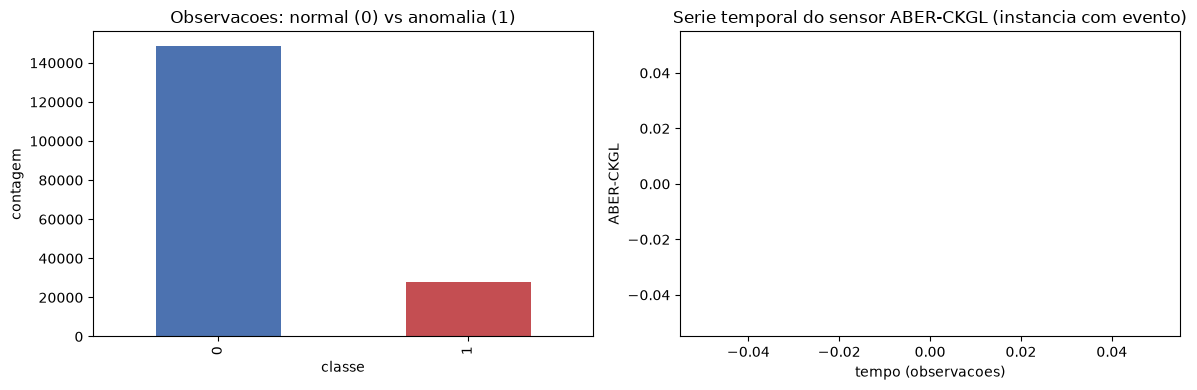

In [32]:
# === Visualizacoes da EDA ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

obs_label.value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=["#4c72b0", "#c44e52"])
axes[0].set_title("Observacoes: normal (0) vs anomalia (1)")
axes[0].set_xlabel("classe"); axes[0].set_ylabel("contagem")

ex = read_instance(anomaly_paths[0])
sensor = feature_cols[0]
axes[1].plot(ex[sensor].values, lw=0.8)
axes[1].set_title("Serie temporal do sensor " + str(sensor) + " (instancia com evento)")
axes[1].set_xlabel("tempo (observacoes)"); axes[1].set_ylabel(str(sensor))

plt.tight_layout(); plt.show()

As visualizações permitem três constatações relevantes.

A primeira diz respeito ao desbalanceamento, anteriormente assumido como premissa e ora confirmado empiricamente: na análise por observação, aproximadamente 84% dos registros correspondem à condição normal e cerca de 16% à anomalia. Não se trata de um desbalanceamento extremo, o que preserva a viabilidade do aprendizado, mas é suficientemente acentuado para tornar a acurácia, isoladamente, uma métrica enganosa, fato que fundamenta a seleção de métricas adotada nas etapas subsequentes.

A segunda refere-se à série temporal apresentada, na qual se observa com clareza a transição de patamar do sensor no momento de instauração do evento. É precisamente essa assinatura dinâmica que se espera que o modelo aprenda a reconhecer. No caso específico do fechamento espúrio da DHSV, a literatura do 3W documenta que a pressão se eleva nos sensores situados a montante da válvula (PDG) e decresce nos posicionados a jusante (TPT e MON-CKP), o que confere coerência física à expectativa de que tais variáveis concentrem o sinal discriminante.


## 3.4. Preparação dos dados


In [33]:
# === Janelamento + extracao de atributos estatisticos ===
WINDOW = 300        # observacoes por janela (~5 min a 1 Hz)
MAX_WINDOWS = 60    # teto de janelas por instancia (controla memoria)
ANOMALY_FRAC = 0.5  # fracao de obs. anomalas p/ rotular a janela como anomalia

def instance_to_windows(path):
    df = read_instance(path)
    y_raw = (df[LABEL_COL].fillna(0).astype(float) != 0).astype(int).values
    X = df[feature_cols].astype(float).values
    out, count, n = [], 0, len(df)
    for start in range(0, n - WINDOW + 1, WINDOW):
        if count >= MAX_WINDOWS:
            break
        sl = slice(start, start + WINDOW)
        win = X[sl]
        feats = np.concatenate([np.nanmean(win, axis=0), np.nanstd(win, axis=0),
                                np.nanmin(win, axis=0),  np.nanmax(win, axis=0)])
        out.append((feats, int(y_raw[sl].mean() >= ANOMALY_FRAC)))
        count += 1
    return out

feat_names = ([c + "_mean" for c in feature_cols] + [c + "_std" for c in feature_cols] +
              [c + "_min"  for c in feature_cols] + [c + "_max" for c in feature_cols])

records, y_list, groups = [], [], []
all_paths = [("normal", p) for p in normal_paths] + [("evento", p) for p in anomaly_paths]
for gid, (src, p) in enumerate(all_paths):
    for feats, label in instance_to_windows(p):
        records.append(feats); y_list.append(label); groups.append(gid)

X_all = pd.DataFrame(records, columns=feat_names).replace([np.inf, -np.inf], np.nan)
X_all = X_all.dropna(axis=1, how="all")
y_all = np.array(y_list); groups = np.array(groups)

print("Matriz de atributos:", X_all.shape)
print("Distribuicao do alvo (janelas):",
      pd.Series(y_all).value_counts(normalize=True).round(3).to_dict())

Matriz de atributos: (1533, 72)
Distribuicao do alvo (janelas): {0: 0.84, 1: 0.16}


A principal decisão desta etapa consiste na conversão das séries temporais em uma representação tabular. Em lugar de submeter os sinais brutos ao modelo, cada instância é segmentada em janelas de tamanho fixo e, para cada janela e cada sensor, computam-se quatro estatísticas descritivas: média, desvio-padrão, mínimo e máximo. Esse procedimento sintetiza a dinâmica local do sinal em atributos compatíveis com modelos clássicos, dispensando arquiteturas de aprendizado profundo, cuja adoção seria desproporcional ao escopo de um MVP. A rotulação de cada janela como anomalia ocorre quando ao menos metade de suas observações é anômala, critério que acomoda de forma adequada os períodos de transição.

O resultado é uma matriz de 1533 janelas por 72 atributos. A dimensão 72 corresponde a 18 sensores multiplicados pelas quatro estatísticas, o que evidencia que, dos 27 sensores originais, 18 foram preservados após a remoção das colunas integralmente ausentes, precisamente os nove sensores identificados com 100% de ausência na análise exploratória. Cumpre observar que o desbalanceamento manteve-se em aproximadamente 16% de anomalia após o janelamento, indicando que a agregação não introduziu distorção na proporção das classes.


## 3.5. Divisão dos dados


In [34]:
# === Divisao treino/teste POR INSTANCIA (evita vazamento) ===
grp_ids = np.unique(groups)
grp_label = np.array([int(y_all[groups == g].mean() >= 0.5) for g in grp_ids])

train_g, test_g = train_test_split(
    grp_ids, test_size=0.30, random_state=RANDOM_STATE,
    stratify=grp_label if len(np.unique(grp_label)) > 1 else None)

train_mask = np.isin(groups, train_g); test_mask = np.isin(groups, test_g)
X_train, X_test = X_all[train_mask], X_all[test_mask]
y_train, y_test = y_all[train_mask], y_all[test_mask]
groups_train = groups[train_mask]

print("Janelas -> treino:", int(train_mask.sum()), "| teste:", int(test_mask.sum()))
print("Proporcao de anomalia (treino/teste):",
      round(float(y_train.mean()), 3), "/", round(float(y_test.mean()), 3))

Janelas -> treino: 1089 | teste: 444
Proporcao de anomalia (treino/teste): 0.159 / 0.162


Esta constitui a decisão metodológica de maior consequência no presente trabalho. Em virtude da elevada correlação entre janelas vizinhas de uma mesma instância, uma divisão aleatória por registro alocaria janelas de um mesmo poço simultaneamente nos conjuntos de treino e de teste, de modo que o modelo seria avaliado sobre dados praticamente já observados. As métricas resultantes seriam artificialmente elevadas e, por conseguinte, não confiáveis.

Por essa razão, a divisão é realizada por instância: a totalidade das janelas de um arquivo é alocada integralmente ao treino ou ao teste, jamais a ambos. Adotou-se estratificação pelo rótulo dominante de cada instância, assegurando a presença da classe anômala em ambos os conjuntos. A partição resultou em 1089 janelas de treino e 444 de teste, com proporções de anomalia praticamente equivalentes (0,159 e 0,162, respectivamente). É essa partição isenta de vazamento que confere validade às demais etapas de avaliação.


## 4. Modelagem

A modelagem contempla a comparação entre um modelo de referência (baseline) e dois modelos candidatos, todos encapsulados em pipelines compostos por imputação, padronização e estimador, de modo a garantir que nenhuma transformação seja ajustada com informação proveniente do conjunto de teste. O baseline consiste na predição sistemática da classe majoritária, estabelecendo o patamar mínimo de desempenho. Os modelos candidatos são a Regressão Logística (linear, interpretável e computacionalmente eficiente) e o Random Forest, capaz de capturar interações não-lineares entre os sensores. Ambos empregam o parâmetro `class_weight="balanced"` em razão do desbalanceamento das classes.


In [35]:
# === Baseline + dois modelos candidatos ===
def make_pipeline(model):
    return Pipeline([("imputer", SimpleImputer(strategy="median")),
                     ("scaler", StandardScaler()),
                     ("model", model)])

models = {
    "Baseline (classe majoritaria)": DummyClassifier(strategy="most_frequent"),
    "Regressao Logistica": make_pipeline(
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    "Random Forest": make_pipeline(
        RandomForestClassifier(n_estimators=200, class_weight="balanced",
                               random_state=RANDOM_STATE, n_jobs=-1)),
}

def evaluate(name, clf):
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    try:
        proba = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, proba); ap = average_precision_score(y_test, proba)
    except Exception:
        auc, ap = np.nan, np.nan
    return {"modelo": name,
            "F1_anomalia": f1_score(y_test, pred, zero_division=0),
            "ROC_AUC": auc, "PR_AUC": ap,
            "F1_treino": f1_score(y_train, clf.predict(X_train), zero_division=0)}

results, fitted = [], {}
for name, m in models.items():
    fitted[name] = m
    results.append(evaluate(name, m))

results_df = pd.DataFrame(results).set_index("modelo").round(3)
results_df

,F1_anomalia,ROC_AUC,PR_AUC,F1_treino
modelo,,,,
Baseline (classe majoritaria),0.000,0.500,0.162,0.000
Regressao Logistica,0.762,0.977,0.826,0.986
Random Forest,0.742,0.989,0.965,0.997


Os resultados são inequívocos. O baseline registrou F1 nulo e ROC-AUC de 0,5, confirmando de maneira concreta a inadequação da acurácia neste contexto: a predição constante da classe normal é desprovida de utilidade, independentemente do volume de acertos acumulado.

Ambos os modelos candidatos superam amplamente o baseline. A Regressão Logística alcançou F1 de 0,762 para a classe anomalia, e o Random Forest, 0,742, valores praticamente equivalentes nesse critério. A análise da PR-AUC, contudo, altera o panorama: o Random Forest registra 0,965 contra 0,826 da Regressão Logística, indicando capacidade de separação das classes substancialmente superior ao longo dos diferentes limiares, ainda que tal vantagem não se reflita no F1 medido no limiar padrão de 0,5. Depreende-se, assim, que a definição do melhor modelo dependerá da métrica privilegiada, questão retomada na discussão.


## 5. Otimização de hiperparâmetros

Procede-se ao ajuste de hiperparâmetros do Random Forest mediante `GridSearchCV` com validação cruzada estratificada, adotando-se o F1 como critério de seleção, em consonância com o foco na classe minoritária. Os hiperparâmetros otimizados são `n_estimators` (relacionado à estabilidade das predições), `max_depth` (controle da complexidade do modelo) e `min_samples_leaf` (regularização das folhas).


In [36]:
# === GridSearchCV no Random Forest ===
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
param_grid = {"model__n_estimators": [200, 400],
              "model__max_depth": [None, 8, 16],
              "model__min_samples_leaf": [1, 3]}

grid = GridSearchCV(
    make_pipeline(RandomForestClassifier(class_weight="balanced",
                                         random_state=RANDOM_STATE, n_jobs=-1)),
    param_grid=param_grid, scoring="f1", cv=cv, n_jobs=-1)
grid.fit(X_train, y_train)

print("Melhores hiperparametros:", grid.best_params_)
print("Melhor F1 (validacao cruzada):", round(grid.best_score_, 3))

best_rf = grid.best_estimator_
results.append(evaluate("Random Forest (tunado)", best_rf))
fitted["Random Forest (tunado)"] = best_rf
results_df = pd.DataFrame(results).set_index("modelo").round(3)
results_df

Melhores hiperparametros: {'model__max_depth': 8, 'model__min_samples_leaf': 3, 'model__n_estimators': 400}
Melhor F1 (validacao cruzada): 0.989


,F1_anomalia,ROC_AUC,PR_AUC,F1_treino
modelo,,,,
Baseline (classe majoritaria),0.000,0.500,0.162,0.000
Regressao Logistica,0.762,0.977,0.826,0.986
Random Forest,0.742,0.989,0.965,0.997
Random Forest (tunado),0.738,0.987,0.950,0.991


O resultado obtido foi de melhoria nula no conjunto de teste: o F1 variou de 0,742 para 0,738, registrando inclusive leve decréscimo. Opta-se por reportar esse desfecho sem ajustes.

Merece atenção o contraste entre o F1 da validação cruzada (0,989) e o F1 efetivamente observado no teste (aproximadamente 0,74). Tal discrepância não é fortuita: a validação cruzada empregada é estratificada por janela e, portanto, incorre parcialmente no mesmo vazamento entre janelas correlacionadas de um mesmo poço que foi evitado na partição principal. A validação cruzada revela-se, assim, otimista, e o ajuste de hiperparâmetros otimizou uma estimativa inflada, o que explica a ausência de transferência do ganho para o teste por instância. Esse achado corrobora o acerto da divisão por instância e aponta o `GroupKFold` como aprimoramento natural.


## 6. Avaliação dos resultados

Em contextos de classes desbalanceadas, a acurácia tende a superestimar o desempenho, uma vez que a predição constante da classe normal já alcançaria aproximadamente 84% de acerto. Por essa razão, a avaliação fundamenta-se no F1 da classe anomalia, na ROC-AUC, na PR-AUC e na matriz de confusão, métricas que refletem de maneira mais fidedigna a capacidade efetiva de detecção do evento raro.


Melhor modelo: Regressao Logistica 

Relatorio de classificacao (teste):
              precision    recall  f1-score   support

      normal       1.00      0.88      0.94       372
    anomalia       0.62      1.00      0.76        72

    accuracy                           0.90       444
   macro avg       0.81      0.94      0.85       444
weighted avg       0.94      0.90      0.91       444



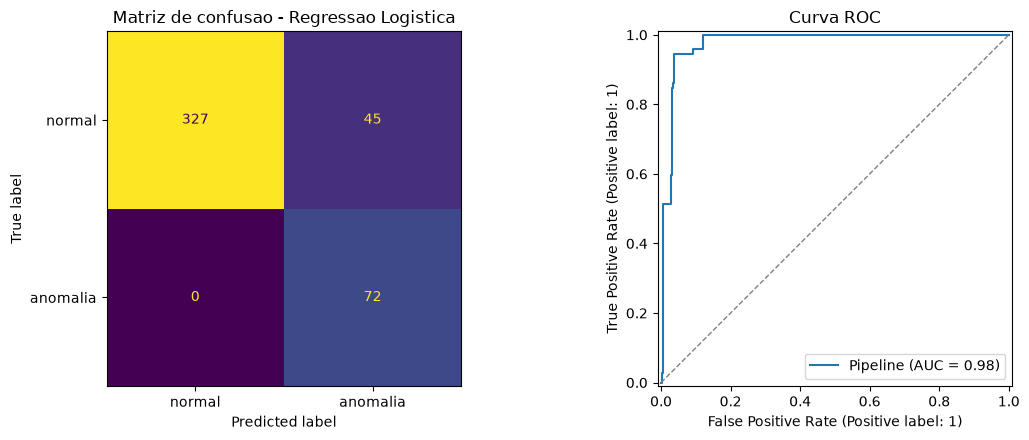

In [37]:
# === Avaliacao detalhada do melhor modelo ===
best_name = results_df["F1_anomalia"].idxmax()
best_model = fitted[best_name]
print("Melhor modelo:", best_name, "\n")

pred = best_model.predict(X_test)
print("Relatorio de classificacao (teste):")
print(classification_report(y_test, pred, target_names=["normal", "anomalia"], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=["normal", "anomalia"], ax=axes[0], colorbar=False)
axes[0].set_title("Matriz de confusao - " + best_name)
try:
    RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1])
    axes[1].plot([0, 1], [0, 1], "--", color="gray", lw=1)
    axes[1].set_title("Curva ROC")
except Exception:
    axes[1].axis("off")
plt.tight_layout(); plt.show()

O relatório de classificação evidencia o compromisso central do problema. Para a classe anomalia, a Regressão Logística apresentou recall de 1,00 e precisão de 0,62. Em termos práticos, o modelo detecta a totalidade dos eventos, sem omissões, ao custo de aproximadamente 40% de falsos alarmes entre os casos sinalizados como anômalos.

Em um sistema de detecção precoce aplicado a poços, esse compromisso reveste-se de particular relevância. A não omissão de eventos é altamente desejável, dado o elevado custo associado a um evento não detectado, o que valoriza o recall elevado. Em contrapartida, a incidência excessiva de falsos alarmes onera o operador e compromete a confiança no sistema. A definição do ponto de equilíbrio entre essas dimensões transcende a escolha do modelo e situa-se no plano operacional, sendo passível de tratamento mediante a calibração do limiar de decisão.


In [38]:
# === Diagnostico de overfitting/underfitting ===
diag = results_df[["F1_treino", "F1_anomalia"]].rename(columns={"F1_anomalia": "F1_teste"})
diag["gap (treino - teste)"] = (diag["F1_treino"] - diag["F1_teste"]).round(3)
diag

,F1_treino,F1_teste,gap (treino - teste)
modelo,,,
Baseline (classe majoritaria),0.000,0.000,0.000
Regressao Logistica,0.986,0.762,0.224
Random Forest,0.997,0.742,0.255
Random Forest (tunado),0.991,0.738,0.253


A coluna referente ao gap é digna de nota: o F1 de treino aproxima-se de 0,99, ao passo que o de teste situa-se em torno de 0,74, configurando uma diferença da ordem de 0,22 a 0,25 nos três modelos não-triviais.

Em uma leitura imediata, tal diferença sugeriria sobreajuste (overfitting) clássico. À luz dos achados da validação cruzada, contudo, impõe-se interpretação mais cuidadosa: parcela significativa desse gap reflete o custo de mensurar a capacidade de generalização de maneira metodologicamente correta. O treino e a validação cruzada operam sobre janelas correlacionadas, enquanto o teste exige acerto em poços não observados, tarefa genuinamente mais difícil. O gap, portanto, não decorre exclusivamente de memorização pelo modelo, mas também do rigor da partição adotada. Reconhece-se a presença de algum grau de sobreajuste, passível de mitigação por meio de maior regularização e ampliação do volume de dados; ainda assim, o desempenho no teste constitui a estimativa em que se deposita confiança.


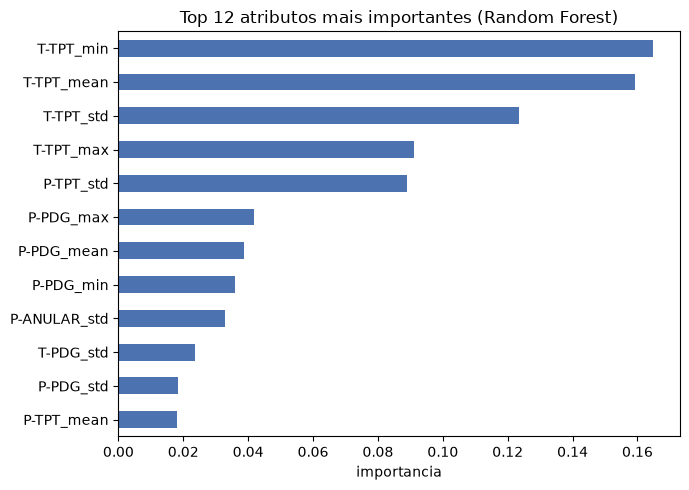

In [39]:
# === Importancia das variaveis (interpretabilidade) ===
rf = fitted.get("Random Forest (tunado)", fitted.get("Random Forest"))
try:
    importances = rf.named_steps["model"].feature_importances_
    imp = pd.Series(importances, index=X_all.columns).sort_values(ascending=False).head(12)
    imp.iloc[::-1].plot(kind="barh", figsize=(7, 5), color="#4c72b0")
    plt.title("Top 12 atributos mais importantes (Random Forest)")
    plt.xlabel("importancia"); plt.tight_layout(); plt.show()
except Exception as e:
    print("Importancia indisponivel:", e)

O gráfico ordena os atributos segundo sua contribuição no Random Forest, revelando o padrão característico no qual um número reduzido de atributos concentra a maior parte da importância, enquanto a cauda longa apresenta contribuição marginal.

Considerando a física do evento, espera-se que figurem entre os mais relevantes os atributos derivados das pressões no entorno da DHSV, visto que a literatura do 3W documenta que, no fechamento espúrio, a pressão se eleva a montante (P-PDG) e decresce a jusante (P-TPT e P-MON-CKP). Recomenda-se verificar, no gráfico, a confirmação desse comportamento: a convergência entre as variáveis privilegiadas pelo modelo e a explicação de engenharia do fenômeno reforça a confiança no resultado, na medida em que indica que a predição não se apoia em associação meramente estatística.


## Comparação e discussão dos resultados

A síntese dos resultados delineia o seguinte quadro. O baseline cumpre a função de estabelecer o patamar mínimo de desempenho (F1 nulo), sendo amplamente superado por ambos os modelos candidatos. No tocante ao F1 da classe anomalia, os modelos apresentam desempenho praticamente equivalente (0,762 para a Regressão Logística e 0,742 para o Random Forest), valor que, todavia, reflete um único ponto de operação, correspondente ao limiar de 0,5.

A análise da capacidade de ordenação dos casos revela superioridade nítida do Random Forest, com PR-AUC de 0,965 contra 0,826 da Regressão Logística, além de ROC-AUC de 0,989 contra 0,977. Tais resultados indicam que o Random Forest discrimina mais eficazmente as classes em termos gerais, e que seu F1 inferior no limiar padrão configura uma questão de calibração do limiar, e não de qualidade intrínseca do modelo. A Regressão Logística, em sua configuração atual, obtém recall pleno (1,00) ao custo de precisão reduzida (0,62), traduzindo-se em volume elevado de falsos alarmes.

Quanto ao sobreajuste, os três modelos exibem gap entre treino e teste da ordem de 0,22 a 0,25 no F1. Parcela dessa diferença decorre de sobreajuste efetivo, porém parte substancial reflete a mensuração da generalização para poços não observados, viabilizada pela divisão por instância. O indício mais robusto desse fenômeno reside na discrepância entre o F1 da validação cruzada (0,989) e o do teste (aproximadamente 0,74): a validação cruzada, estratificada por janela, mostra-se otimista por agregar janelas correlacionadas de um mesmo poço. A antecipação desse risco motivou a opção por não embaralhar observações na partição principal.

Reconhecem-se as seguintes limitações: a utilização de um subconjunto reduzido do 3W (15 instâncias por classe) e de um único tipo de evento; a não adoção de validação cruzada agrupada por poço na etapa de ajuste; e o descarte de cerca de um terço dos sensores em razão de ausência integral de dados. Como desdobramentos naturais, propõem-se: a substituição da validação cruzada por `GroupKFold`, eliminando o vazamento residual no ajuste; a calibração do limiar de decisão segundo o custo operacional relativo entre falso alarme e evento não detectado; a ampliação do número de instâncias e de tipos de evento; o enriquecimento dos atributos com medidas de tendência e de conteúdo espectral; e a avaliação de algoritmos de gradient boosting.


## 7. Conclusão

O objetivo proposto, classificar trechos de sinais de sensoriamento de poços offshore quanto à condição normal ou anômala, foi integralmente cumprido. Empregou-se o 3W Dataset da Petrobras, de domínio público e licenciado sob CC BY 4.0, carregado por URL sem qualquer configuração manual, com enfoque no evento de fechamento espúrio da DHSV.

Entre os tratamentos determinantes para o resultado, destacam-se o janelamento das séries com extração de atributos estatísticos por sensor, a remoção das colunas desprovidas de dados, a imputação e a padronização conduzidas internamente ao pipeline (prevenindo vazamento) e, sobretudo, a divisão entre treino e teste realizada por instância, e não por registro.

Foram comparados o baseline, a Regressão Logística e o Random Forest, este último também submetido a ajuste de hiperparâmetros. Embora a Regressão Logística tenha registrado o maior F1 no teste (0,762), recomenda-se o Random Forest como solução, em razão de sua capacidade superior de separação das classes (PR-AUC de 0,965 contra 0,826) e do potencial de aprimoramento mediante calibração do limiar, ajustada ao custo operacional, com vistas ao melhor equilíbrio entre a detecção dos eventos e a contenção dos falsos alarmes.

As limitações do trabalho são assumidas de forma explícita: subconjunto reduzido, único tipo de evento, validação cruzada não-agrupada na etapa de ajuste e expressiva ausência de sensores. Não obstante, o MVP atende plenamente à finalidade a que se propôs e, em especial, articula uma narrativa coerente (do problema e dos dados à interpretação crítica dos resultados), sem qualquer superestimação de desempenho. Os desdobramentos de maior valor consistem na adoção do `GroupKFold`, na calibração do limiar de decisão e na ampliação da base de dados.


## Respostas ao checklist

O checklist sugerido é empregado como roteiro de verificação, respondendo-se aos itens aplicáveis ao problema.

**Definição do problema.** Classificação de trechos de sensoriamento de poço quanto à condição normal ou anômala; o objetivo é detectar a anomalia com recall elevado sem comprometimento por falsos alarmes; trata-se de classificação binária supervisionada; a pertinência do enfoque de Machine Learning decorre da relação multivariada e não-linear entre os sinais e o evento; as premissas centrais são o desbalanceamento e a correlação temporal intra-instância; a restrição autoimposta consistiu na manutenção de acesso público e de execução leve no Colab.

**Descrição dos dados.** Dataset 3W (Petrobras), carregado via API pública do GitHub; o evento utilizado foi o fechamento espúrio da DHSV; após o janelamento, obtiveram-se 1533 janelas e 72 atributos; a variável-alvo deriva da coluna `class` binarizada; as limitações conhecidas compreendem os valores ausentes (nove sensores integralmente vazios no subconjunto), as durações heterogêneas entre instâncias e o desbalanceamento.

**Preparação dos dados.** A incidência de valores ausentes foi expressiva: as colunas integralmente vazias foram removidas e os valores faltantes remanescentes, imputados pela mediana no interior do pipeline; foram criados novos atributos (média, desvio-padrão, mínimo e máximo por sensor e por janela); aplicou-se padronização ajustada exclusivamente ao treino, sendo a prevenção de vazamento o princípio norteador.

**Divisão dos dados.** Partição treino/teste por instância, estratificada pelo rótulo dominante; adotou-se validação cruzada na etapa de ajuste (estratificada), indicando-se o `GroupKFold` como aprimoramento; a ordem temporal foi respeitada pela não-aleatorização das observações.

**Modelagem.** Baseline de classe majoritária; modelos Regressão Logística e Random Forest, comparados sob conjuntos e pipelines idênticos; o sobreajuste/subajuste foi avaliado pelo gap entre treino e teste.

**Otimização.** Ajuste do Random Forest por meio de GridSearchCV com otimização do F1, sobre os hiperparâmetros n_estimators, max_depth e min_samples_leaf; o ganho no teste foi nulo, e inclusive levemente negativo, fato discutido à luz do caráter otimista da validação cruzada.

**Avaliação.** Métricas adotadas: F1 da classe anomalia, ROC-AUC, PR-AUC e matriz de confusão, adequadas a dados desbalanceados; o maior F1 coube à Regressão Logística, e a melhor separação, ao Random Forest; as principais limitações constam da discussão.

**Conclusão.** Recomenda-se o Random Forest como solução, em razão de sua superioridade em PR-AUC e da margem de aprimoramento via calibração do limiar; os desdobramentos encontram-se na seção 7.

Os itens específicos de previsão de séries temporais e de clusterização não se aplicam, dado que o problema é de classificação supervisionada.
